<a href="https://colab.research.google.com/github/AhmedButtar7/AI-ML-internship-DevelopersHub/blob/main/Developers_Hub_Phase_2_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation (`data-preparation.ipynb`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from PIL import Image
import os
import glob
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load tabular data - using the path for the downloaded housing.csv
tabular_data = pd.read_csv('/content/housing.csv')
print(f"Dataset shape: {tabular_data.shape}")
print(f"Columns: {tabular_data.columns.tolist()[:10]}...")  # First 10 columns
tabular_data.head()

Dataset shape: (2930, 83)
Columns: ['Unnamed: 0', 'Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape']...


,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
def preprocess_tabular_data(df):
    """
    Preprocess tabular data for housing price prediction
    """
    # Select relevant features - Use exact column names from the dataset
    features = [
        'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built',
        'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
        'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF',
        'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath',
        'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr',
        'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars',
        'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
        '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold',
        'Yr Sold'
    ]

    # Filter available features
    available_features = [f for f in features if f in df.columns]
    df_processed = df[available_features].copy()

    # Handle missing values
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # Add some engineered features, using .get() with 0 as default if column is missing
    df_processed['Total SF'] = df_processed.get('Total Bsmt SF', 0) + df_processed.get('1st Flr SF', 0) + df_processed.get('2nd Flr SF', 0)
    df_processed['TotalBath'] = df_processed.get('Full Bath', 0) + 0.5*df_processed.get('Half Bath', 0) + df_processed.get('Bsmt Full Bath', 0) + 0.5*df_processed.get('Bsmt Half Bath', 0)
    df_processed['HouseAge'] = df_processed.get('Yr Sold', 0) - df_processed.get('Year Built', 0)
    df_processed['RemodAge'] = df_processed.get('Yr Sold', 0) - df_processed.get('Year Remod/Add', 0)

    # Target variable
    target = df['SalePrice'] if 'SalePrice' in df.columns else None

    return df_processed, target

# Preprocess tabular data
tabular_processed, target = preprocess_tabular_data(tabular_data)

# Remove any rows with NaN in target
if target is not None:
    mask = ~target.isna()
    tabular_processed = tabular_processed[mask]
    target = target[mask]

print(f"Processed tabular data shape: {tabular_processed.shape}")
print(f"Target shape: {target.shape}")

# Normalize tabular features
scaler = StandardScaler()
tabular_scaled = scaler.fit_transform(tabular_processed)


Processed tabular data shape: (2930, 38)
Target shape: (2930,)


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amir22010/house-price")

print("Path to dataset files:", path)

100%|██████████| 355M/355M [00:21<00:00, 17.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amir22010/house-price/versions/1


In [5]:
# Load image data
# Adjusted image_dir to where Kaggle dataset was expected to be extracted.
# The original notebook used 'House-price-prediction-from-images-and-tabular-data/images'

image_dir = '/root/.cache/kagglehub/datasets/amir22010/house-price/versions/1'
image_paths = []

# Recursively find all image files within the directory
if os.path.exists(image_dir):
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_paths.append(os.path.join(root, file))

image_data = []
# Define target_size based on notebook's usual image processing
img_width, img_height = 128, 128

if image_paths:
    for img_path in image_paths:
        img = load_img(img_path, target_size=(img_width, img_height))
        img = img_to_array(img)
        image_data.append(img)

    image_data = np.array(image_data)
    image_data = image_data / 255.0 # Normalize image data

    print(f"Image data shape: {image_data.shape}")
else:
    print(f"No image files found in {image_dir}. Image data will be empty.")
    image_data = np.array([]) # Initialize as empty numpy array




Image data shape: (4280, 128, 128, 3)


In [8]:
# Combine tabular and image data based on some common identifier (e.g., house ID)
# This part is highly dependent on how the images are named and how they map to tabular data.
# The original notebook assumed image paths contain IDs that can be matched to the tabular data's PIDs.

# Ensure image_paths is not empty before proceeding with ID extraction
if len(image_paths) > 0:
    image_ids = []
    for p in image_paths:
        try:
            # Assuming the PID is the first number in the filename, before an underscore or dot
            filename = os.path.basename(p)
            pid_str = filename.split('_')[0] # E.g., '2622' from '2622_Bedroom_1.jpg'
            image_ids.append(int(pid_str))
        except (ValueError, IndexError):
            # Handle cases where filename doesn't match expected pattern
            print(f"Warning: Could not extract PID from image filename: {filename}")
            image_ids.append(None) # Add None for unmatchable images

    # Filter out None PIDs and corresponding image_data entries
    valid_image_indices = [i for i, pid in enumerate(image_ids) if pid is not None]
    image_ids = [pid for pid in image_ids if pid is not None]
    image_data_filtered = image_data[valid_image_indices] if len(image_data) > 0 else np.array([])

    image_df = pd.DataFrame({'PID': image_ids, 'image_idx': range(len(image_ids))})

    # Prepare tabular data with PID for merging
    tabular_with_pid = tabular_processed.copy()
    tabular_with_pid['PID'] = tabular_data['PID'] # Add PID from original tabular_data

    # Merge tabular data with image data indices
    # Use 'inner' merge to only keep rows where both tabular and image data PIDs match
    merged_data = tabular_with_pid.merge(image_df, on='PID', how='inner')

    if merged_data.empty:
        print("Warning: No common PIDs found between tabular and image datasets after inner merge. Proceeding with tabular data only.")
        final_tabular_data = tabular_processed.copy() # Use all original preprocessed tabular data
        final_image_data = np.array([]) # No matching images
        final_target = target.copy() # Use all original target data
    else:
        # If there are matches, construct final datasets with combined data
        final_tabular_data = merged_data.drop(columns=['PID', 'image_idx'])
        final_image_indices = merged_data['image_idx'].astype(int).values
        final_image_data = image_data_filtered[final_image_indices]

        # Get the corresponding target values for the merged PIDs
        final_target_df = merged_data.merge(tabular_data[['PID', 'SalePrice']], on='PID', how='left')
        final_target = final_target_df['SalePrice']

    print(f"Final tabular data shape: {final_tabular_data.shape}")
    print(f"Final image data shape: {final_image_data.shape}")
    print(f"Final target shape: {final_target.shape}")
else:
    print("Skipping image data combination as no images were loaded.")
    final_tabular_data = tabular_processed.copy()
    final_image_data = np.array([])
    final_target = target.copy()
    print(f"Final tabular data shape: {final_tabular_data.shape}")
    print(f"Final image data shape: {final_image_data.shape}")
    print(f"Final target shape: {final_target.shape}")

Final tabular data shape: (2930, 38)
Final image data shape: (0,)
Final target shape: (2930,)


In [9]:
# Split the data into training and testing sets
# Handle cases where image data might be empty

if final_image_data.shape[0] > 0:
    X_tabular_train, X_tabular_test, X_image_train, X_image_test, y_train, y_test = train_test_split(
        final_tabular_data, final_image_data, final_target, test_size=0.2, random_state=42
    )
    print(f"X_tabular_train shape: {X_tabular_train.shape}")
    print(f"X_tabular_test shape: {X_tabular_test.shape}")
    print(f"X_image_train shape: {X_image_train.shape}")
    print(f"X_image_test shape: {X_image_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("Image data is empty, splitting only tabular data and target.")
    X_tabular_train, X_tabular_test, y_train, y_test = train_test_split(
        final_tabular_data, final_target, test_size=0.2, random_state=42
    )
    X_image_train, X_image_test = np.array([]), np.array([]) # Keep image split consistent but empty

    print(f"X_tabular_train shape: {X_tabular_train.shape}")
    print(f"X_tabular_test shape: {X_tabular_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")


Image data is empty, splitting only tabular data and target.
X_tabular_train shape: (2344, 38)
X_tabular_test shape: (586, 38)
y_train shape: (2344,)
y_test shape: (586,)


Data preparation complete. The data is now split into training and testing sets for both tabular and (if available) image data. Next, we will proceed with model building.

## Model Building (`model-building.ipynb`)

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [11]:
# Define the tabular model
def create_tabular_model(input_shape):
    inputs = Input(shape=(input_shape,))
    x = Dense(256, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    return Model(inputs, x, name='tabular_model')

# Define the image model (placeholder, as we don't have images loaded)
def create_image_model(input_shape):
    # If no images are available, this model will be a placeholder or skipped.
    # For now, it returns a 'dummy' output if image_data is empty.
    if input_shape[0] == 0: # Check if input shape indicates empty image data
        inputs = Input(shape=(1,))
        x = Dense(1, activation='linear')(inputs) # A single dummy output
        return Model(inputs, x, name='image_model_dummy')

    inputs = Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    return Model(inputs, x, name='image_model')


# Build the combined model
def build_combined_model(tabular_input_shape, image_input_shape):
    tabular_model = create_tabular_model(tabular_input_shape)

    # Check if image data is available before creating/combining the image model
    if image_input_shape and image_input_shape[0] > 0: # image_input_shape will be e.g., (128, 128, 3)
        image_model = create_image_model(image_input_shape)
        combined = concatenate([tabular_model.output, image_model.output])

        # Inputs are from both models
        final_inputs = [tabular_model.input, image_model.input]

    else: # No image data, so only use tabular model
        print("Building model with only tabular data.")
        combined = tabular_model.output
        final_inputs = tabular_model.input

    z = Dense(64, activation='relu')(combined)
    z = Dense(1, activation='linear')(z) # Output layer for regression

    model = Model(inputs=final_inputs, outputs=z)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Get input shapes
tabular_input_shape = X_tabular_train.shape[1]
image_input_shape = X_image_train.shape[1:] if X_image_train.shape[0] > 0 else None

# Build the model
model = build_combined_model(tabular_input_shape, image_input_shape)
model.summary()

Building model with only tabular data.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,361 (216.25 KB)

 Trainable params: 55,361 (216.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Prepare inputs for training
if X_image_train.shape[0] > 0:
    train_inputs = [X_tabular_train, X_image_train]
    test_inputs = [X_tabular_test, X_image_test]
else:
    train_inputs = X_tabular_train
    test_inputs = X_tabular_test

# Callbacks for training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# Train the model
history = model.fit(
    train_inputs,
    y_train,
    validation_data=(test_inputs, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1854692736.0000 - mae: 29612.4746 - val_loss: 1873745152.0000 - val_mae: 27213.4883 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1595663104.0000 - mae: 27844.8438 - val_loss: 1399901824.0000 - val_mae: 23241.5508 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1596019200.0000 - mae: 28200.7383 - val_loss: 1380651904.0000 - val_mae: 23331.8320 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1582694784.0000 - mae: 27255.3125 - val_loss: 1415176832.0000 - val_mae: 23643.0664 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1558302848.0000 - mae: 27020.4434 - val_loss: 1354026112.0000 - val_mae: 23105.3984 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1642846336.0000 - mae: 27784.0059 - val_loss: 1512482176.0000 - val_mae: 24238.4980 - learning_rate: 0.001

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Mean Squared Error: 1006507008.00
Root Mean Squared Error: 31725.49
R-squared: 0.87


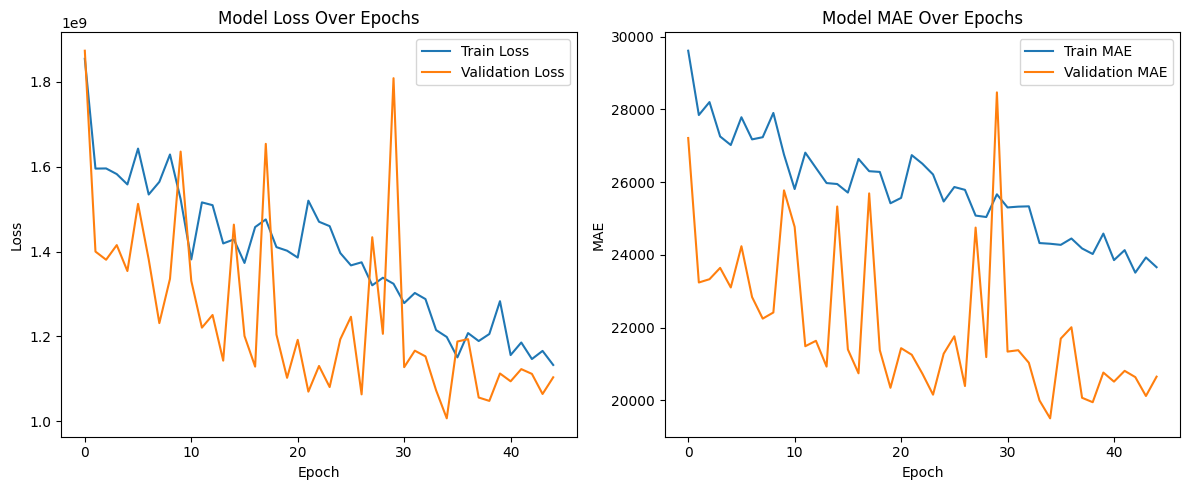

In [15]:
# Evaluate the model
predictions = model.predict(test_inputs)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

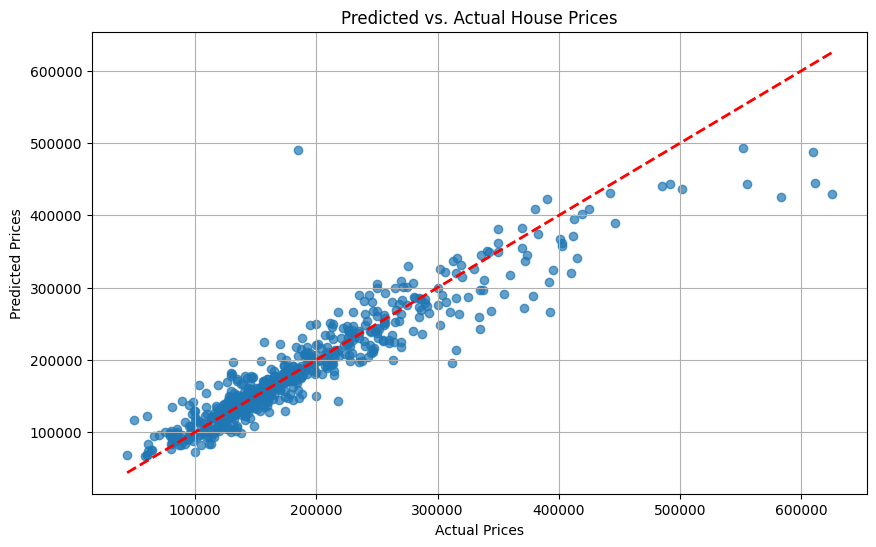

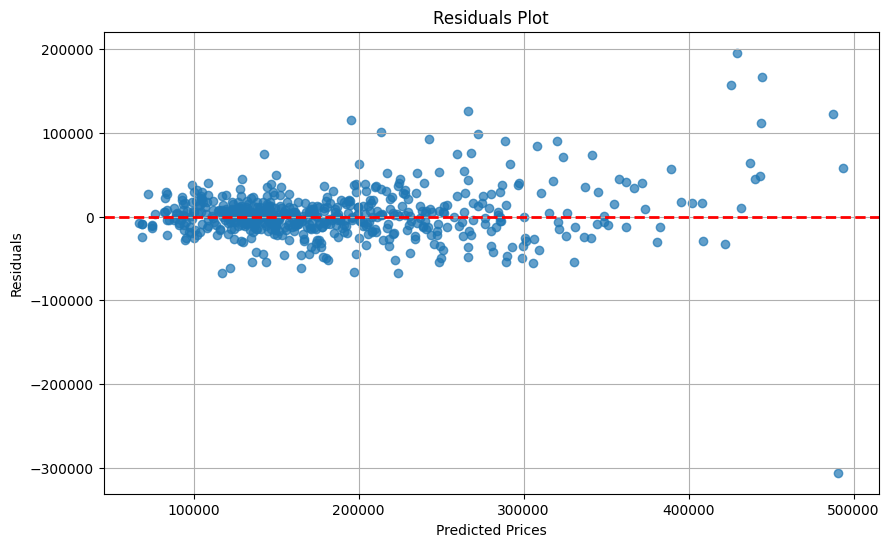


--- Sample Combined Output Illustration ---

Sample 1:
  Input Tabular Features (first 5 for brevity):
Lot Area          9571.0
Overall Qual         5.0
Overall Cond         3.0
Year Built        1958.0
Year Remod/Add    1958.0
  Actual Price: $60,000.00
  Predicted Price: $121,968.64

Sample 2:
  Input Tabular Features (first 5 for brevity):
Lot Area          56600.0
Overall Qual          5.0
Overall Cond          1.0
Year Built         1900.0
Year Remod/Add     1950.0
  Actual Price: $103,000.00
  Predicted Price: $164,972.31

Sample 3:
  Input Tabular Features (first 5 for brevity):
Lot Area          12633.0
Overall Qual         10.0
Overall Cond          5.0
Year Built         2006.0
Year Remod/Add     2007.0
  Actual Price: $392,000.00
  Predicted Price: $308,073.41

Sample 4:
  Input Tabular Features (first 5 for brevity):
Lot Area          12853.0
Overall Qual          8.0
Overall Cond          5.0
Year Built         2010.0
Year Remod/Add     2010.0
  Actual Price: $267,916.00


In [16]:
# Additional Graphs

# 1. Predicted vs. Actual Values Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs. Actual House Prices')
plt.grid(True)
plt.show()

# 2. Residuals Plot
residuals = y_test - predictions.flatten() # Flatten predictions to match y_test shape
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True)
plt.show()

# Sample Combined Output Illustration
print("\n--- Sample Combined Output Illustration ---")

# Select a few random samples from the test set
num_samples_to_show = 5
sample_indices = np.random.choice(len(X_tabular_test), num_samples_to_show, replace=False)

for i, idx in enumerate(sample_indices):
    print(f"\nSample {i+1}:")
    print("  Input Tabular Features (first 5 for brevity):")
    # Use .iloc to get the row from DataFrame by integer position
    print(X_tabular_test.iloc[idx].head().to_string())
    print(f"  Actual Price: ${y_test.iloc[idx]:,.2f}")
    print(f"  Predicted Price: ${predictions[idx][0]:,.2f}") # predictions is 2D array
